In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import zipfile

IMG_SIZE = 64
DATA_ZIP_PATH = '/content/images.zip'
DATA_DIR = '/content/images' # Extracted directory

# Unzip the file if it hasn't been unzipped already
if not os.path.exists(DATA_DIR):
    with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/')

X = []
y = []

# Check if the extracted directory exists and has contents
if os.path.exists(DATA_DIR) and os.listdir(DATA_DIR):
    class_names = os.listdir(DATA_DIR)

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(DATA_DIR, class_name)
        # Ensure it's a directory before listing
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    img = img / 255.0
                    X.append(img.flatten())
                    y.append(label)
else:
    print(f"Error: Directory '{DATA_DIR}' not found or is empty after extraction.")

if len(X) > 0:
    X = np.array(X)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"Successfully loaded {len(X)} images.")
else:
    print("No images were loaded. Please check the dataset structure.")


Successfully loaded 309 images.


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}


Accuracy: 0.6612903225806451
              precision    recall  f1-score   support

       pizza       0.78      0.64      0.70        11
 soccer_ball       0.45      0.38      0.42        13
   dalmatian       0.50      0.73      0.59        11
 dollar_bill       0.86      0.60      0.71        10
   sunflower       0.79      0.88      0.83        17

    accuracy                           0.66        62
   macro avg       0.68      0.65      0.65        62
weighted avg       0.68      0.66      0.66        62



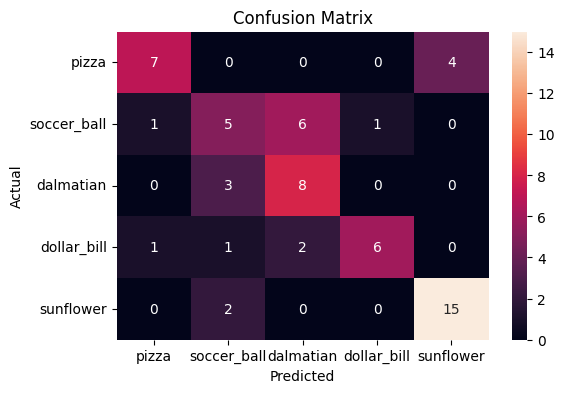

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

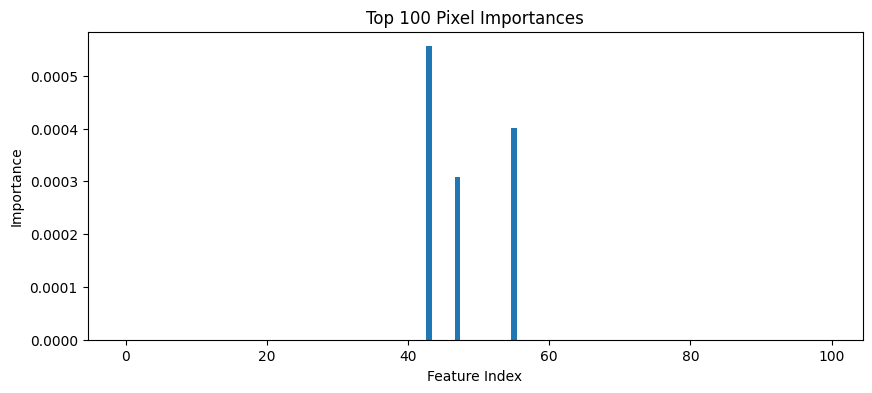

In [5]:
importances = best_rf.feature_importances_

plt.figure(figsize=(10, 4))
plt.bar(range(100), importances[:100])
plt.title("Top 100 Pixel Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [7]:
import os
import cv2
import numpy as np

def create_dummy_image(path, size=(IMG_SIZE, IMG_SIZE), color=(255, 0, 0)):
    if not os.path.exists(path):
        dummy_img = np.zeros((*size, 3), dtype=np.uint8)
        dummy_img[:] = color # Set image to a solid color (e.g., red)
        cv2.imwrite(path, dummy_img)
        print(f"Created dummy image at {path}")

# Ensure a test image exists for prediction
test_image_path = '/content/test_image.jpg'
create_dummy_image(test_image_path)

def predict_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return f"Error: Could not load image from {image_path}"

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = img.flatten().reshape(1, -1)

    prediction = best_rf.predict(img)[0]
    return class_names[prediction]

print("Predicted class:", predict_image(test_image_path))


Created dummy image at /content/test_image.jpg
Predicted class: dalmatian


In [8]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10)
svm.fit(X_train, y_train)

y_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_svm))
print(classification_report(y_test, y_svm, target_names=class_names))

SVM Accuracy: 0.7741935483870968
              precision    recall  f1-score   support

       pizza       0.80      0.73      0.76        11
 soccer_ball       0.67      0.77      0.71        13
   dalmatian       0.67      0.73      0.70        11
 dollar_bill       0.83      0.50      0.62        10
   sunflower       0.89      1.00      0.94        17

    accuracy                           0.77        62
   macro avg       0.77      0.74      0.75        62
weighted avg       0.78      0.77      0.77        62

